<a href="https://colab.research.google.com/github/riyaashukla30/AI-ML-Internship-Project/blob/main/face_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install face-recognition
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=ae1fc51bbd2ca53b024a28a5840e121033f5a0058ad5980fc04d69c4a1ec9297
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [2]:
!pip install face-recognition opencv-python matplotlib

In [4]:
from google.colab import files
uploaded = files.upload()

Saving riya1.jpeg to riya1 (1).jpeg


In [5]:
from google.colab import files
uploaded = files.upload()

Saving riya2.jpeg to riya2.jpeg


In [6]:
from google.colab import files
uploaded = files.upload()

Saving riya4.jpeg to riya4.jpeg


In [7]:
from google.colab import files
uploaded = files.upload()

Saving riya5.jpeg to riya5.jpeg


In [8]:
import face_recognition
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [13]:
import os
os.listdir()

['.config',
 'riya4.jpeg',
 'riya1.jpeg',
 'riya1 (1).jpeg',
 'riya2.jpeg',
 'riya5.jpeg',
 'sample_data']

In [14]:
import os
os.remove("riya1 (1).jpeg")

In [15]:
known_encodings = []
known_names = []

image_files = ["riya1.jpeg", "riya2.jpeg", "riya4.jpeg", "riya5.jpeg"]

for file in image_files:
    image = face_recognition.load_image_file(file)
    encodings = face_recognition.face_encodings(image)

    if len(encodings) > 0:
        known_encodings.append(encodings[0])
        known_names.append("Riya")
    else:
        print(f"⚠️ No face found in {file}")

print("✅ Encoding Complete")

✅ Encoding Complete


In [20]:
from google.colab import files
uploaded = files.upload()

Saving test..jpeg to test..jpeg


In [21]:
test_image = face_recognition.load_image_file("test..jpeg")
rgb_image = test_image.copy()

In [22]:
face_locations = face_recognition.face_locations(test_image)
face_encodings = face_recognition.face_encodings(test_image, face_locations)

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    matches = face_recognition.compare_faces(known_encodings, face_encoding)
    name = "Unknown"

    if True in matches:
        matched_idxs = [i for i, val in enumerate(matches) if val]
        counts = {}

        for i in matched_idxs:
            name = known_names[i]
            counts[name] = counts.get(name, 0) + 1

        name = max(counts, key=counts.get)

    # Draw box
    cv2.rectangle(rgb_image, (left, top), (right, bottom), (0, 255, 0), 2)
    cv2.putText(rgb_image, name, (left, top - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

print("✅ Recognition Done")

✅ Recognition Done


(np.float64(-0.5), np.float64(719.5), np.float64(1279.5), np.float64(-0.5))

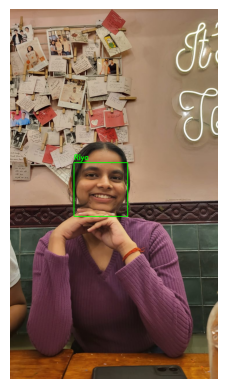

In [23]:
from matplotlib import pyplot as plt

plt.imshow(rgb_image)
plt.axis("off")

In [31]:
import os
os.listdir()

['.config',
 'riya4.jpeg',
 'riya1.jpeg',
 'test1.jpeg',
 'test2.jpeg',
 'riya2.jpeg',
 'riya5.jpeg',
 'sample_data']

In [32]:
test_images = [
    ("test1.jpeg", "Riya"),     # if this is your face
    ("test2.jpeg", "Unknown")   # if this is someone else
]

correct = 0
total = 0

for file, true_name in test_images:
    image = face_recognition.load_image_file(file)
    locations = face_recognition.face_locations(image)
    encodings = face_recognition.face_encodings(image, locations)

    for encoding in encodings:
        matches = face_recognition.compare_faces(known_encodings, encoding)
        predicted = "Unknown"

        if True in matches:
            matched_idxs = [i for i, val in enumerate(matches) if val]
            counts = {}

            for i in matched_idxs:
                name = known_names[i]
                counts[name] = counts.get(name, 0) + 1

            predicted = max(counts, key=counts.get)

        print(f"{file} → Predicted: {predicted}, Actual: {true_name}")

        if predicted == true_name:
            correct += 1

        total += 1

accuracy = (correct / total) * 100
print(f"\n✅ Accuracy: {accuracy:.2f}%")

test1.jpeg → Predicted: Riya, Actual: Riya
test2.jpeg → Predicted: Riya, Actual: Unknown

✅ Accuracy: 50.00%


✅ Advanced Recognition Done


(np.float64(-0.5), np.float64(467.5), np.float64(1039.5), np.float64(-0.5))

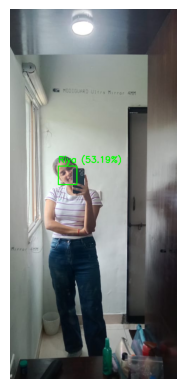

In [33]:
import face_recognition
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load test image
test_image = face_recognition.load_image_file("test1.jpeg")
rgb_image = test_image.copy()

# Detect faces
face_locations = face_recognition.face_locations(test_image)
face_encodings = face_recognition.face_encodings(test_image, face_locations)

threshold = 0.5   # You can tune this (0.4 = strict, 0.6 = loose)

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    distances = face_recognition.face_distance(known_encodings, face_encoding)

    if len(distances) > 0:
        best_match_index = np.argmin(distances)
        min_distance = distances[best_match_index]

        if min_distance < threshold:
            name = known_names[best_match_index]

            # Convert distance to confidence
            confidence = (1 - min_distance) * 100
            label = f"{name} ({confidence:.2f}%)"
        else:
            label = "Unknown"
    else:
        label = "Unknown"

    # Draw box + label
    cv2.rectangle(rgb_image, (left, top), (right, bottom), (0, 255, 0), 2)
    cv2.putText(rgb_image, label, (left, top - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

print("✅ Advanced Recognition Done")

# Show image
plt.imshow(rgb_image)
plt.axis("off")